In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

import os
os.makedirs("../results/04", exist_ok = True)

In [5]:
df = pd.read_csv("../data/processed/tpd_2018_2025.csv", low_memory = False)
df.head()

,IncidentID,Year,Month,Day,Hour,Division,Ward,UCR,UCRDescription,Offense,CallSource
0,112318516Z,2022,January,Sat,0,West,0,6,06 - LARCENY,603,Web Reported
1,009240162Z,2022,March,Tue,13,West,1,2,02 - SEXUAL ASSAULT,203,Unknown
2,1210180043,2019,February,Tue,3,South,5,1,01 - HOMICIDE,101,Unknown
3,1801010290,2018,January,Mon,10,West,1,7,07 - GTA,701,Call For Service
4,1801010146,2018,January,Mon,4,South,5,4,"04 - ASSAULT, AGGRAVATED",403,Call For Service


In [6]:
# drop columns not used
df = df.drop(columns = ["IncidentID", "UCR", "Offense"])

# one-hot encode
df_encoded = pd.get_dummies(df, columns = ["Division", "CallSource", "Ward", "Month", "Day"], drop_first = True)

# using same selected features from classification
selected_features = ['Hour', 'Year', 'CallSource_Web Reported', 'CallSource_Officer-Initiated', 
                     'Day_Mon', 'Day_Thu', 'Day_Wed', 'Day_Tue', 'Day_Sat', 'Day_Sun', 
                     'Month_May', 'Month_March', 'Month_October', 'Month_January', 
                     'Month_February', 'Month_July', 'Month_August', 'Month_June', 
                     'Month_September', 'Month_November', 'Month_December', 'Division_Midtown']

X = df_encoded[selected_features]

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(243127, 22)

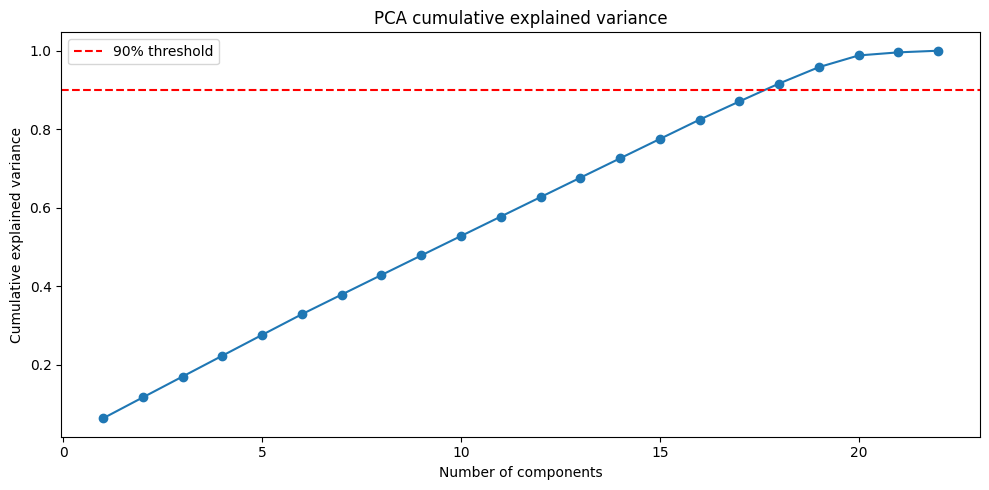

In [7]:
# Principal Component Analysis (PCA)

pca = PCA(random_state = 42)
pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize = (10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker = "o")
plt.axhline(y = 0.90, color = "r", linestyle = "--", label = "90% threshold")
plt.title("PCA cumulative explained variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.tight_layout()
plt.savefig("../results/04/pca_explained_variance.png", dpi = 150, bbox_inches = "tight")
plt.show()

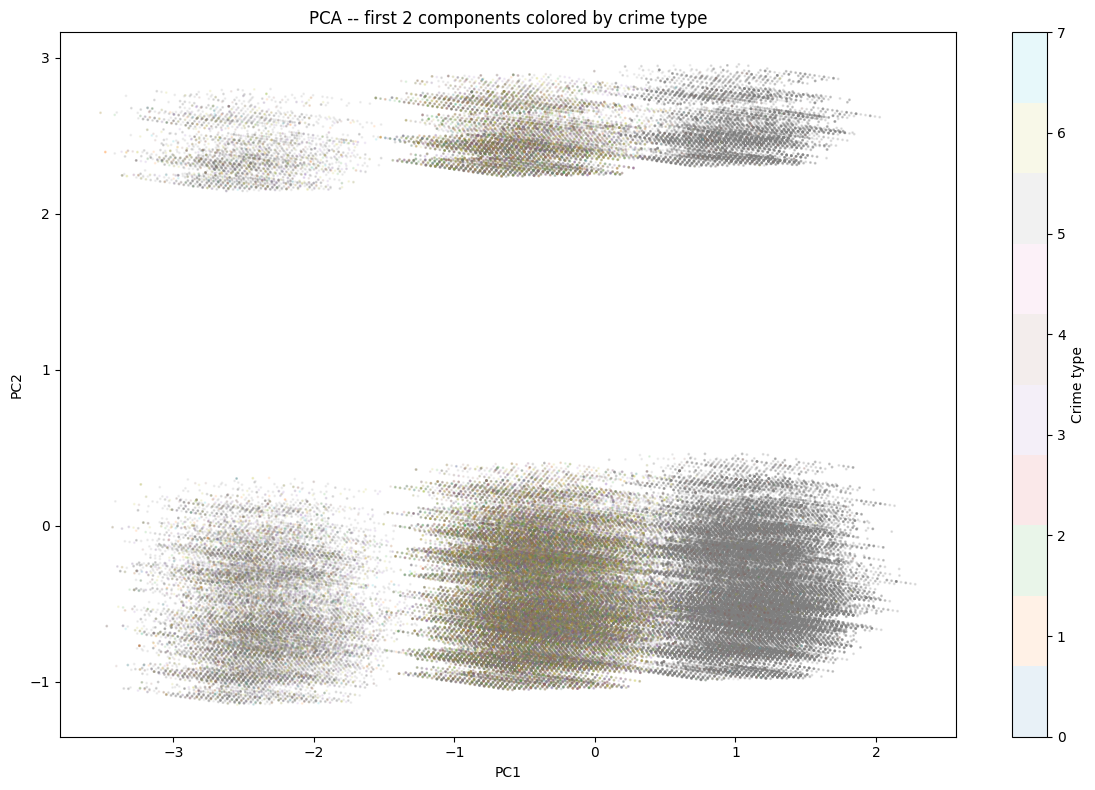

In [8]:
# 1st 2 PCs

pca_2d = PCA(n_components = 2, random_state = 42)
X_pca = pca_2d.fit_transform(X_scaled)
le = LabelEncoder()
y_encoded = le.fit_transform(df["UCRDescription"])

plt.figure(figsize = (12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c = y_encoded, cmap = "tab10", alpha = 0.1, s = 1)
plt.colorbar(scatter, label = "Crime type")
plt.title("PCA -- first 2 components colored by crime type")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("../results/04/pca_2d.png", dpi = 150, bbox_inches = "tight")
plt.show()

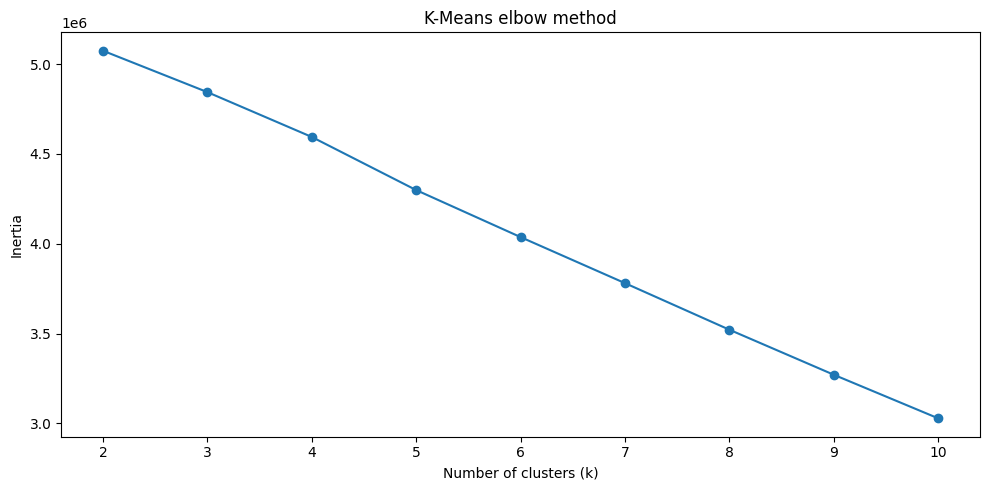

In [9]:
# K-means clustering

inertias = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize = (10, 5))
plt.plot(k_range, inertias, marker = "o")
plt.title("K-Means elbow method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig("../results/04/kmeans_elbow.png", dpi = 150, bbox_inches = "tight")
plt.show()